Setup & Connection

Import required libraries and connect to the DuckDB database.
Run this cell first.

In [15]:
import os
import warnings
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

db_path = "capstone_dev.duckdb"
if not os.path.exists(db_path):
    db_path = "../capstone_dev.duckdb"

con = duckdb.connect(db_path)

def fmt_dollar(value):
    return f"${value:,.2f}"

print("Database connected.")

Database connected.


📦 Product Profitability

Shows total profit generated by each product and compares it with units sold.

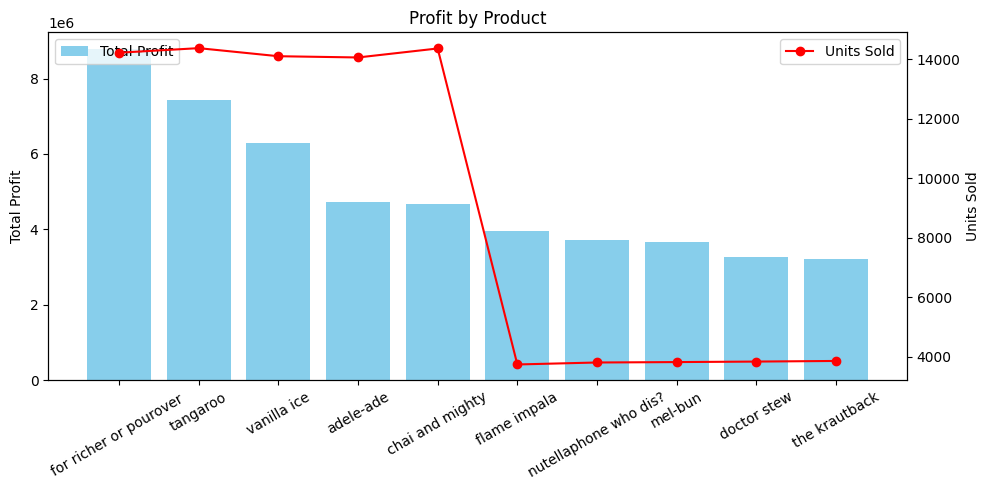

           product_name  total_sold gross_revenue  total_profit
for richer or pourover        14217 $9,951,900.00 $8,786,106.00
               tangaroo       14370 $8,622,000.00 $7,443,660.00
            vanilla ice       14099 $8,459,400.00 $6,288,154.00
              adele-ade       14057 $5,622,800.00 $4,737,209.00
        chai and mighty       14359 $7,179,500.00 $4,666,675.00
           flame impala        3744 $5,241,600.00 $3,957,408.00
  nutellaphone who dis?        3810 $4,191,000.00 $3,729,990.00
                mel-bun        3824 $4,588,800.00 $3,674,864.00
            doctor stew        3841 $4,225,100.00 $3,261,009.00
          the krautback        3862 $4,634,400.00 $3,220,908.00


In [16]:
df_products = con.execute("""
    SELECT
        product_name,
        total_sold,
        gross_revenue,
        total_profit
    FROM main.dim_products
    WHERE total_sold > 0
    ORDER BY total_profit DESC
""").df()

fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(
    df_products["product_name"],
    df_products["total_profit"],
    color="skyblue",
    label="Total Profit"
)

ax1.set_title("Profit by Product")
ax1.set_ylabel("Total Profit")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
line = ax2.plot(
    df_products["product_name"],
    df_products["total_sold"],
    marker="o",
    color="red",
    label="Units Sold"
)

ax2.set_ylabel("Units Sold")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

summary = df_products.copy()
summary["gross_revenue"] = summary["gross_revenue"].map(fmt_dollar)
summary["total_profit"] = summary["total_profit"].map(fmt_dollar)

print(summary.to_string(index=False))

🏪 Store Performance

Compare revenue, profit, and profit margin across store locations.

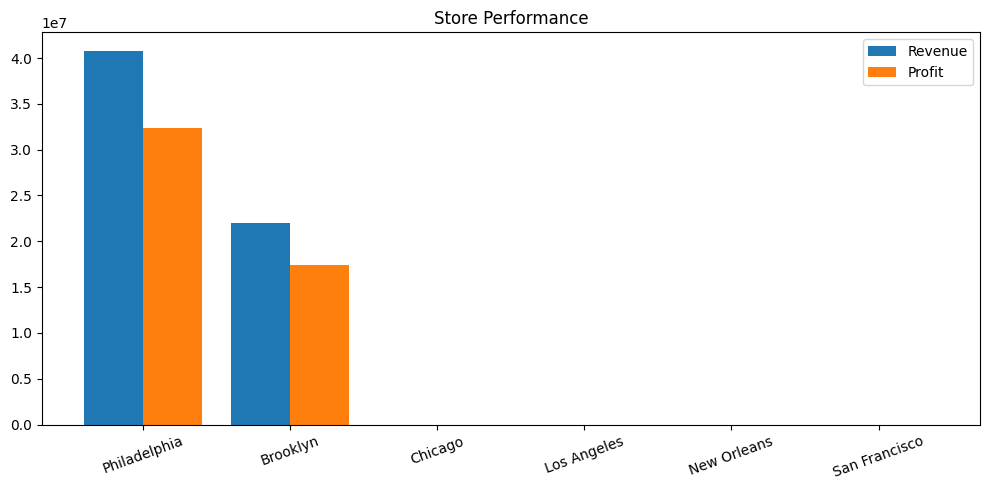

   store_name  total_revenue   total_profit profit_margin_pct
 Philadelphia $40,771,600.00 $32,357,542.00             79.4%
     Brooklyn $21,944,900.00 $17,408,441.00             79.3%
      Chicago          $0.00          $0.00              0.0%
  Los Angeles          $0.00          $0.00              0.0%
  New Orleans          $0.00          $0.00              0.0%
San Francisco          $0.00          $0.00              0.0%


In [17]:
df_stores = con.execute("""
    SELECT
        store_name,
        total_revenue,
        total_profit,
        profit_margin_pct
    FROM main.dim_stores
    ORDER BY total_revenue DESC
""").df()

fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(df_stores))
width = 0.4

ax.bar([i - width/2 for i in x],
       df_stores["total_revenue"],
       width,
       label="Revenue")

ax.bar([i + width/2 for i in x],
       df_stores["total_profit"],
       width,
       label="Profit")

ax.set_title("Store Performance")
ax.set_xticks(list(x))
ax.set_xticklabels(df_stores["store_name"], rotation=20)
ax.legend()

plt.tight_layout()
plt.show()

summary = df_stores.copy()
summary["total_revenue"] = summary["total_revenue"].map(fmt_dollar)
summary["total_profit"] = summary["total_profit"].map(fmt_dollar)
summary["profit_margin_pct"] = summary["profit_margin_pct"].map(lambda x: f"{x:.1f}%")

print(summary.to_string(index=False))

👑 Top Customer Lifetime Value

Displays the top 10 customers ranked by lifetime spending.

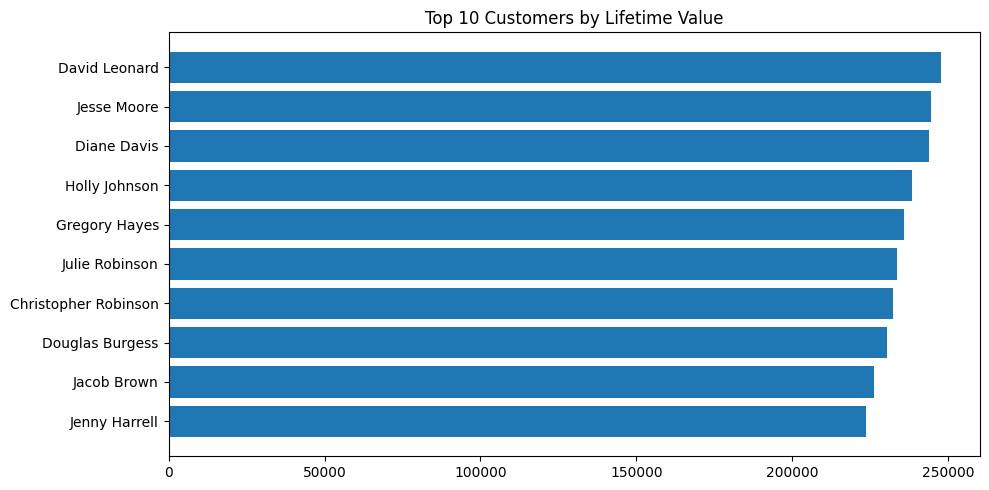

       customer_name lifetime_value avg_purchase
       David Leonard    $247,800.00    $2,031.15
         Jesse Moore    $244,400.00    $2,350.00
         Diane Davis    $243,900.00    $2,322.86
       Holly Johnson    $238,400.00    $5,297.78
       Gregory Hayes    $235,700.00    $2,223.58
      Julie Robinson    $233,500.00    $5,306.82
Christopher Robinson    $232,400.00    $2,020.87
     Douglas Burgess    $230,300.00    $2,214.42
         Jacob Brown    $226,100.00    $1,916.10
       Jenny Harrell    $223,700.00    $2,130.48


In [18]:
df_customers = con.execute("""
    SELECT
        first_name || ' ' || last_name AS customer_name,
        lifetime_value,
        avg_purchase
    FROM main.mart_most_valuable_customer
    WHERE lifetime_value > 0
    ORDER BY lifetime_value DESC
    LIMIT 10
""").df()

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(df_customers["customer_name"],
        df_customers["lifetime_value"])

ax.set_title("Top 10 Customers by Lifetime Value")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

summary = df_customers.copy()
summary["lifetime_value"] = summary["lifetime_value"].map(fmt_dollar)
summary["avg_purchase"] = summary["avg_purchase"].map(fmt_dollar)

print(summary.to_string(index=False))

🏁 5 · Wrap-up

Close the DuckDB connection and confirm all three PNG exports were written.

In [19]:
con.close()
print('done')

done
